In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

class backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 64, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        return self.features(x)


class head(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(1024 * 7 * 7, 4096),
            nn.LeakyReLU(0.1),
            # ← no Dropout here, matches what was actually trained
            nn.Linear(4096, 7 * 7 * 50)
        )

    def forward(self, x):
        return self.features(x)


class YOLO(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = backbone()
        self.head = head()

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        x = x.view(-1, 7, 7, 50)
        return x

In [3]:
def encode_target(annotation, grid_size=7):
    target = torch.zeros(grid_size, grid_size, 50)
    size = annotation['annotation']['size']
    img_w = float(size['width'])
    img_h = float(size['height'])

    for obj in annotation['annotation']['object']:
        class_name = obj['name']
        if class_name not in VOC_CLASSES:
            continue
        class_idx = VOC_CLASSES.index(class_name)
        xmin = float(obj['bndbox']['xmin']) / img_w
        ymin = float(obj['bndbox']['ymin']) / img_h
        xmax = float(obj['bndbox']['xmax']) / img_w
        ymax = float(obj['bndbox']['ymax']) / img_h

        x_center = (xmin + xmax) / 2
        y_center = (ymin + ymax) / 2
        width    = xmax - xmin
        height   = ymax - ymin

        col = min(int(x_center * grid_size), grid_size - 1)
        row = min(int(y_center * grid_size), grid_size - 1)

        x_cell = x_center * grid_size - col
        y_cell = y_center * grid_size - row

        if target[row, col, 4] == 0:
            target[row, col, 0:5] = torch.tensor([x_cell, y_cell, width, height, 1])
            target[row, col, 10 + class_idx] = 1

    return target


class VOCDataset(Dataset):
    def __init__(self, root, image_set='val', transform=None):
        self.transform = transform
        self.dataset = datasets.VOCDetection(
            root=root, year='2012',
            image_set=image_set, download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, annotation = self.dataset[idx]
        image = image.resize((448, 448))
        if self.transform:
            image = self.transform(image)
        target = encode_target(annotation)
        return image, target


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_dataset = VOCDataset(root='data', image_set='val', transform=transform)
val_loader  = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

100%|██████████| 2.00G/2.00G [00:58<00:00, 34.5MB/s]


In [4]:
eval_model = YOLO()
eval_model = nn.DataParallel(eval_model)

# Load and strip the extra 'module.' prefix
state_dict = torch.load('/kaggle/input/models/joercharles/eval/pytorch/default/1/yolo_epoch_170.pth', map_location=device)
state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}

eval_model.module.load_state_dict(state_dict)
eval_model = eval_model.to(device)
eval_model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
def non_max_suppression(boxes, iou_threshold=0.5, conf_threshold=0.25):
    """boxes: list of [x, y, w, h, confidence, class_idx]"""
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [
            b for b in boxes
            if b[5] != best[5] or  # different class
            iou(
                torch.tensor(best[:4]).unsqueeze(0),
                torch.tensor(b[:4]).unsqueeze(0)
            ).item() < iou_threshold
        ]
    return kept


def decode_predictions(output, conf_threshold=0.25):
    """Convert raw 7x7x50 output to a list of boxes."""
    boxes = []
    output = output.squeeze(0)  # (7, 7, 50)
    for row in range(7):
        for col in range(7):
            cell = output[row, col]
            for b in range(2):
                offset = b * 5
                conf = cell[offset + 4].item()
                if conf < conf_threshold:
                    continue
                x_cell = cell[offset + 0].item()
                y_cell = cell[offset + 1].item()
                w      = cell[offset + 2].item()
                h      = cell[offset + 3].item()

                # Convert to image-relative coords
                x = (col + x_cell) / 7
                y = (row + y_cell) / 7

                class_scores = cell[10:]
                class_idx = class_scores.argmax().item()
                score = conf * class_scores[class_idx].item()

                if score > conf_threshold:
                    boxes.append([x, y, w, h, score, class_idx])
    return non_max_suppression(boxes)

In [6]:
def iou(box1, box2):
    x1 = torch.max(box1[..., 0] - box1[..., 2]/2, box2[..., 0] - box2[..., 2]/2)
    y1 = torch.max(box1[..., 1] - box1[..., 3]/2, box2[..., 1] - box2[..., 3]/2)
    x2 = torch.min(box1[..., 0] + box1[..., 2]/2, box2[..., 0] + box2[..., 2]/2)
    y2 = torch.min(box1[..., 1] + box1[..., 3]/2, box2[..., 1] + box2[..., 3]/2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = box1[..., 2] * box1[..., 3]
    box2_area = box2[..., 2] * box2[..., 3]
    union = box1_area + box2_area - intersection

    return intersection / (union + 1e-6)


def non_max_suppression(boxes, iou_threshold=0.5, conf_threshold=0.25):
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda x: x[4], reverse=True)
    kept = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [
            b for b in boxes
            if b[5] != best[5] or
            iou(
                torch.tensor(best[:4]).unsqueeze(0),
                torch.tensor(b[:4]).unsqueeze(0)
            ).item() < iou_threshold
        ]
    return kept


def decode_predictions(output, conf_threshold=0.25):
    boxes = []
    output = output.squeeze(0)
    for row in range(7):
        for col in range(7):
            cell = output[row, col]
            for b in range(2):
                offset = b * 5
                conf = cell[offset + 4].item()
                if conf < conf_threshold:
                    continue
                x_cell = cell[offset + 0].item()
                y_cell = cell[offset + 1].item()
                w      = cell[offset + 2].item()
                h      = cell[offset + 3].item()

                x = (col + x_cell) / 7
                y = (row + y_cell) / 7

                class_scores = cell[10:]
                class_idx = class_scores.argmax().item()
                score = conf * class_scores[class_idx].item()

                if score > conf_threshold:
                    boxes.append([x, y, w, h, score, class_idx])
    return non_max_suppression(boxes)

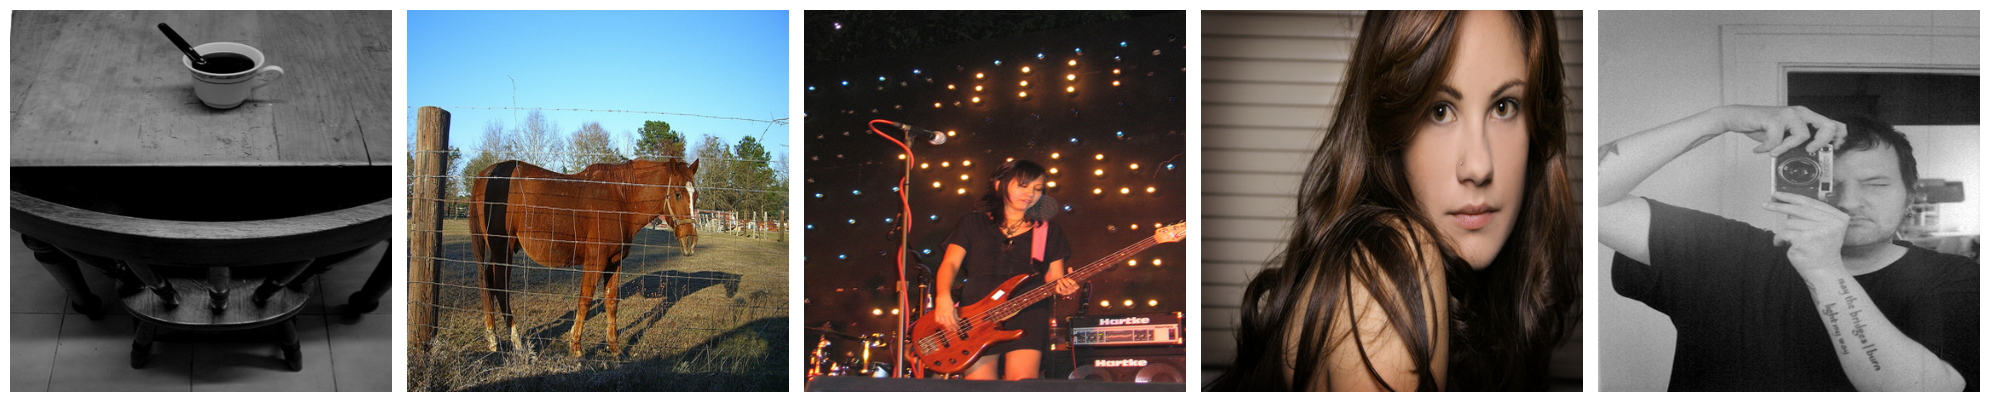

Saved as detections.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_predictions(model, val_dataset, num_images=5, conf_threshold=0.25):
    model.eval()
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))

    indices = np.random.choice(len(val_dataset), num_images, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = val_dataset[idx]
            output = model(image.unsqueeze(0).to(device))
            output = output.cpu()

            boxes = decode_predictions(output, conf_threshold)

            # Unnormalize for display
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            display_img = (image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

            ax = axes[i]
            ax.imshow(display_img)
            ax.axis('off')

            for box in boxes:
                x, y, w, h, score, class_idx = box
                x1 = (x - w/2) * 448
                y1 = (y - h/2) * 448
                bw = w * 448
                bh = h * 448
                rect = patches.Rectangle(
                    (x1, y1), bw, bh,
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, f"{VOC_CLASSES[class_idx]} {score:.2f}",
                        color='red', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.5, pad=1))

    plt.tight_layout()
    plt.savefig('detections.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved as detections.png")

visualize_predictions(eval_model, val_dataset, num_images=5)

In [8]:
from collections import defaultdict

def compute_map(model, loader, iou_threshold=0.5, conf_threshold=0.25):
    model.eval()
    all_preds  = defaultdict(list)  # class -> [(conf, tp)]
    all_gt_count = defaultdict(int) # class -> total gt boxes

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            outputs = model(images).cpu()

            for i in range(len(images)):
                preds = decode_predictions(outputs[i].unsqueeze(0), conf_threshold)
                target = targets[i]

                # Collect ground truth boxes
                gt_boxes = defaultdict(list)
                for row in range(7):
                    for col in range(7):
                        if target[row, col, 4] == 1:
                            cls = target[row, col, 10:].argmax().item()
                            box = target[row, col, 0:4].tolist()
                            # Convert to image coords
                            x = (col + box[0]) / 7
                            y = (row + box[1]) / 7
                            gt_boxes[cls].append([x, y, box[2], box[3]])
                            all_gt_count[cls] += 1

                matched = defaultdict(set)
                for pred in sorted(preds, key=lambda x: -x[4]):
                    cls = pred[5]
                    best_iou, best_j = 0, -1
                    for j, gt in enumerate(gt_boxes[cls]):
                        iou_val = iou(
                            torch.tensor(pred[:4]).unsqueeze(0),
                            torch.tensor(gt).unsqueeze(0)
                        ).item()
                        if iou_val > best_iou:
                            best_iou, best_j = iou_val, j
                    tp = 1 if best_iou >= iou_threshold and best_j not in matched[cls] else 0
                    if tp:
                        matched[cls].add(best_j)
                    all_preds[cls].append((pred[4], tp))

    # Compute AP per class
    aps = []
    print(f"\n{'Class':<16} {'AP':>6}")
    print("-" * 24)
    for cls in range(20):
        if all_gt_count[cls] == 0:
            continue
        preds_cls = sorted(all_preds[cls], key=lambda x: -x[0])
        tp_cumsum = fp_cumsum = 0
        precisions, recalls = [], []
        total_gt = all_gt_count[cls]
        for conf, tp in preds_cls:
            if tp:
                tp_cumsum += 1
            else:
                fp_cumsum += 1
            precisions.append(tp_cumsum / (tp_cumsum + fp_cumsum))
            recalls.append(tp_cumsum / total_gt)
        # Compute area under PR curve
        ap = sum(
            (recalls[i] - (recalls[i-1] if i > 0 else 0)) * precisions[i]
            for i in range(len(precisions))
        )
        aps.append(ap)
        print(f"{VOC_CLASSES[cls]:<16} {ap:.4f}")

    mean_ap = sum(aps) / len(aps) if aps else 0
    print("-" * 24)
    print(f"{'mAP':<16} {mean_ap:.4f}")
    return mean_ap

map_score = compute_map(eval_model, val_loader)


Class                AP
------------------------
aeroplane        0.1596
bicycle          0.0545
bird             0.0003
boat             0.0037
bottle           0.0000
bus              0.0979
car              0.0251
cat              0.0340
chair            0.0000
cow              0.0000
diningtable      0.0000
dog              0.0121
horse            0.0028
motorbike        0.0245
person           0.0230
pottedplant      0.0000
sheep            0.0008
sofa             0.0000
train            0.0080
tvmonitor        0.0025
------------------------
mAP              0.0224
